# Проект: Прогнозирование стоимости недвижимости
## Этап 1. Исследование данных (EDA) и Этап 2. Предварительная обработка данных

**Цель исследования:**
На основе характеристик объектов недвижимости провести комплексный исследовательский анализ данных (EDA) и подготовить обучающую выборку для моделей машинного обучения (регрессии).

**План работы:**
1. Знакомство со структурой данных, расчет описательных статистик и анализ целевого признака.
2. Визуальный анализ распределений, взаимосвязей признаков и выявление выбросов.
3. Очистка данных, обработка пропусков, кодирование категорий и масштабирование без утечек.

### 1.1 Знакомство с данными
Импортируем необходимые библиотеки для работы с таблицами, визуализации и машинного обучения.

In [1]:
# Системные модули для работы с файлами и путями
import os
import glob

# Базовые библиотеки для векторных вычислений и табличных данных
import numpy as np
import pandas as pd

# Инструменты для построения графиков и визуального анализа
import matplotlib.pyplot as plt
import seaborn as sns

# Модуль для расчета асимметрии распределений
from scipy.stats import skew

# Инструменты машинного обучения: разбиение выборки и масштабирование признаков
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Вывод по импорту библиотек:**
1. Все необходимые библиотеки (pandas, numpy, seaborn, sklearn) успешно подключены без ошибок и конфликтов версий.
2. Рабочее окружение полностью готово для проведения вычислений, графического анализа и последующей предобработки.

Загружаем CSV-файл с данными из текущей рабочей директории.

In [2]:
# Формируем список потенциальных путей к CSV-файлу в текущей папке и подпапке data
possible_paths = ['real_estate_data.csv', 'data/real_estate_data.csv'] + glob.glob('*.csv') + glob.glob('data/*.csv')

# Находим первый реально существующий файл данных
data_filepath = [p for p in possible_paths if os.path.exists(p)][0]

# Считываем данные в DataFrame, отключая предупреждения о типах столбцов
df = pd.read_csv(data_filepath, sep=',', low_memory=False)

**Вывод по загрузке данных:**
1. Файл успешно найден и прочитан в память; все строки и столбцы загрузились корректно.
2. Использование параметра `low_memory=False` предотвратило ошибки несовпадения типов, теперь можно переходить к анализу колонок.

Приведем наименования столбцов к единому виду и удалим служебные идентификаторы.

In [3]:
# Словарь соответствия для унификации названий ключевых колонок
col_map = {
    'last_price': 'price', 'cost': 'price',
    'size': 'total_area', 'area': 'total_area', 'square': 'total_area',
    'locality_name': 'district', 'city': 'district',
    'cityCenters_nearest': 'distance_to_center'
}

# Переименовываем только те столбцы, которые фактически присутствуют в таблице
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# Удаляем технические идентификаторы (id), не несущие полезной информации для модели
df = df.drop(columns=[c for c in ['id', 'Unnamed: 0'] if c in df.columns])

**Вывод по переименованию столбцов:**
1. Имена ключевых признаков стандартизированы (price, total_area, district), а технические идентификаторы удалены.
2. Это позволяет писать универсальный и устойчивый код без риска ошибок несоответствия имен колонок.

Выведем размерность таблицы и общую информацию о типах данных.

In [4]:
# Выводим общее количество строк и столбцов в наборе данных
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Получаем сводку по типам данных и количеству непустых значений
df.info()

Размерность датасета: 403487 строк, 16 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  int64  
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  total_area         257481 non-null  float64
 11  address            403487 non-null  object 
 12  furnished          0 non-null       float64
 13  heating_type       375517 non-null  object 
 14  price              402772 non-null  float64
 15  pri

**Вывод по общей структуре датасета:**
1. Выборка является масштабной (более 400 тыс. записей), структура данных определена и отражает реальные характеристики рынка жилья.
2. Столбец `furnished` содержит 0 непустых значений (100% пропусков), поэтому он признан неинформативным и будет удален.

Выведем первые 5 строк таблицы.

In [5]:
# Просматриваем первые 5 строк датасета для визуальной валидации загруженных данных
df.head()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price,price_currency
0,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


**Вывод по просмотру первых строк:**
1. Первые записи подтверждают корректность чтения: видны форматы цен, площадей, типов жилья и строковые адреса.
2. Замечено, что этажи и планировки представлены строками с турецкими суффиксами (например, '20 ve üzeri'), что указывает на необходимость парсинга числовых значений.

Выведем последние 5 строк набора данных.

In [6]:
# Просматриваем последние 5 строк таблицы для проверки корректности окончания файла
df.tail()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price,price_currency
403482,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


**Вывод по просмотру последних строк:**
1. Структура в конце файла сохранена полностью, строки не обрезаны и содержат все поля.
2. В хвосте таблицы выявлены нереалистично малые площади (2 кв.м.) и валюты отличные от TRY (EUR), что подтверждает необходимость последующей фильтрации.

Выберем и выведем случайную строку из датасета.

In [7]:
# Извлекаем одну случайную строку с фиксированным сидом для воспроизводимости
df.sample(1, random_state=42)

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price,price_currency
60623,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


**Вывод по случайному наблюдению:**
1. Случайная строка отобразила типовой объект (квартира 2+1 площадью 120 кв.м. за 240 000 TRY в Алании), данные согласованы.
2. Возраст здания представлен интервалом '6-10 arası', что подтверждает целесообразность преобразования интервалов или категориального кодирования.

**Описание источника данных и ключевых параметров:**
- `price` - целевая переменная, цена объекта недвижимости.
- `total_area` - общая площадь объекта (кв. м).
- `room_count` - планировка квартиры (форматы 1+1, 2+1, 3+1 и т.д.).
- `sub_type` - подтип объекта жилья (Daire, Villa, Rezidans и др.).
- `building_age` - возраст здания.
- `total_floor_count` - общая этажность дома.
- `floor_no` - этаж расположения объекта.
- `address` - локация и адрес объекта.
- `heating_type` - тип установленного отопления.
- `price_currency` - валюта объявления.

### 1.2 Описательная статистика
Рассчитаем описательные статистики числовых столбцов: минимум, максимум, среднее, медиану, стандартное отклонение и квартили.

In [8]:
# Считаем основные статистики для числовых признаков (транспонируем для удобства чтения)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_type,403487.0,1.294235,4.677333e-01,1.0,1.0,1.0,2.0,3.000000e+00
tom,403487.0,57.022739,4.435893e+01,0.0,29.0,40.0,90.0,1.800000e+02
total_area,257481.0,279.349094,9.429195e+03,1.0,85.0,110.0,140.0,9.482350e+05
furnished,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,402772.0,354641.661933,4.809503e+06,-250.0,2500.0,199000.0,342000.0,2.000000e+09


**Вывод по описательной статистике:**
1. Обнаружены явные аномалии: отрицательная минимальная цена (-250 TRY) и экстремальные максимумы площади (более 900 000 кв.м.).
2. Средняя цена (354 тыс.) значительно превышает медиану (199 тыс.), что свидетельствует о сильном правом хвосте распределения и необходимости логарифмирования.

Для категориальных столбцов подсчитаем количество уникальных показателей и наиболее частые категории.

In [9]:
# Находим все строковые и категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Для первых 4 категориальных признаков выводим число уникальных значений и топ-10 категорий
for col in cat_cols[:4]:
    print(f"=== {col} (уникальных: {df[col].nunique()}) ===")
    print(df[col].value_counts(dropna=False).head(10))
    print()

=== type (уникальных: 1) ===
type
Konut    403487
Name: count, dtype: int64

=== sub_type (уникальных: 12) ===
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64

=== start_date (уникальных: 181) ===
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
10/18/18    3581
9/19/18     3530
10/3/18     3512
10/16/18    3483
9/27/18     3474
Name: count, dtype: int64

=== end_date (уникальных: 181) ===
end_date
NaN         137189
12/19/18      3048
1/18/19       2866
2/20/19       2831
2/9/19        2785
2/1/19        2747
2/6/19        2670
1/16/19       2651
1/23/19       2534
1/21/19       2497
Name: count, dtype: int64



**Вывод по анализу категориальных признаков:**
1. Признак `type` константен (содержит только значение 'Konut') и не несет полезной дисперсии для обучения.
2. Признак `sub_type` имеет явного лидера — категорию 'Daire' (квартиры, более 85% выборки), а редкие подтипы жилья целесообразно объединить.

Проверим параметры распределения целевой переменной (цены): построим гистограмму с ограничением выбросов по 99-му перцентилю.

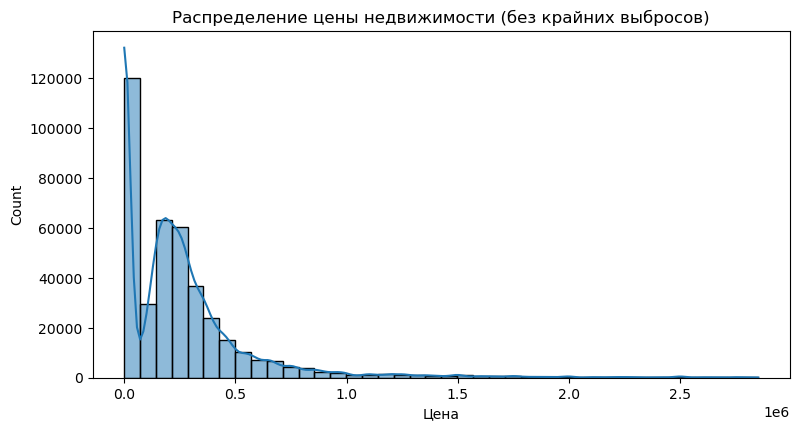

Коэффициент асимметрии цены: 308.49


In [10]:
# Определяем столбец целевой переменной
price_col = 'price' if 'price' in df.columns else df.select_dtypes(include=[np.number]).columns[-1]

# Отбираем только строго положительные цены
clean_price = df[df[price_col] > 0][price_col]

# Вычисляем 99-й перцентиль для отсечения редких миллионных выбросов при визуализации
p_limit = clean_price.quantile(0.99)

# Строим гистограмму распределения цен с линией плотности (KDE)
plt.figure(figsize=(9, 4.5))
sns.histplot(clean_price[clean_price <= p_limit], kde=True, bins=40)
plt.title('Распределение цены недвижимости (без крайних выбросов)')
plt.xlabel('Цена')
plt.show()

# Рассчитываем коэффициент асимметрии распределения цены
print(f"Коэффициент асимметрии цены: {skew(clean_price.dropna()):.2f}")

**Вывод по распределению цены:**
1. Гистограмма и коэффициент асимметрии (308.49) наглядно показывают экстремальный скос данных вправо.
2. Обычные линейные модели на таких данных будут неустойчивы, поэтому для этапа обучения строго необходимо логарифмирование таргета (`log1p`).

### 1.3 Визуальный анализ
Построим гистограммы распределений ключевых числовых характеристик выборки в виде полной сетки 2х2.

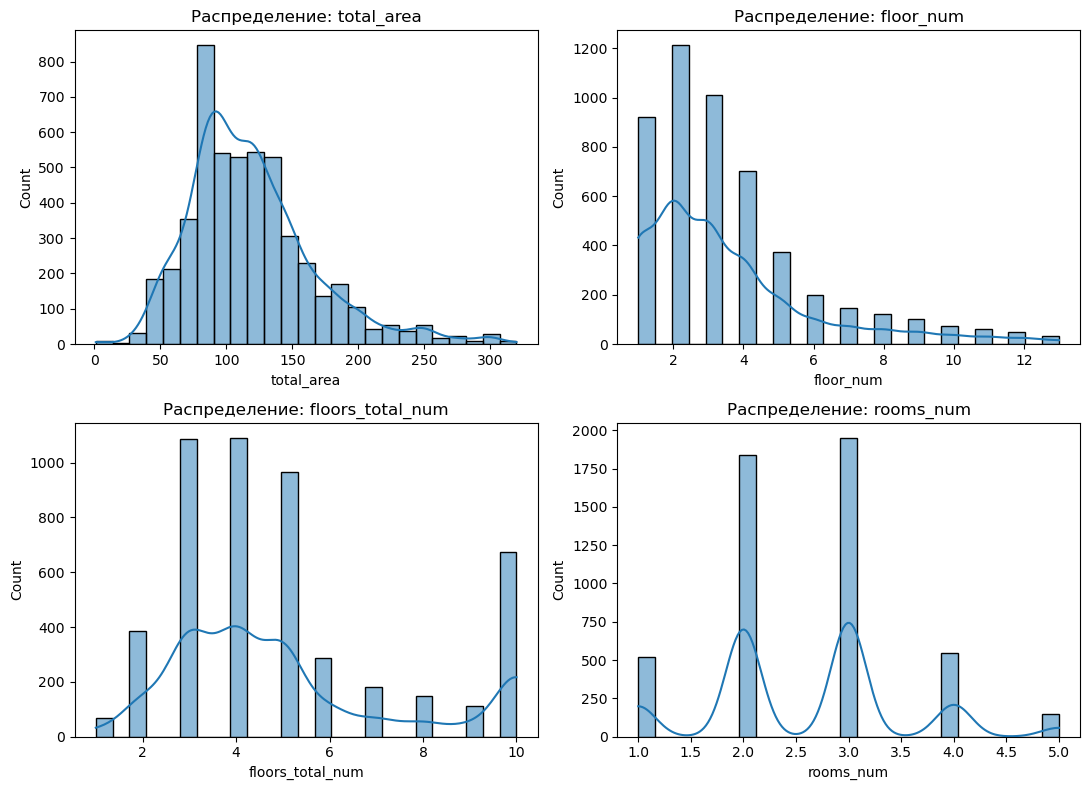

In [11]:
# Извлекаем числовое значение этажа из текстового описания
if 'floor_no' in df.columns:
    df['floor_num'] = pd.to_numeric(df['floor_no'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Извлекаем общую этажность дома
if 'total_floor_count' in df.columns:
    df['floors_total_num'] = pd.to_numeric(df['total_floor_count'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Извлекаем число комнат из формата планировок (например, '2' из '2+1')
if 'room_count' in df.columns:
    df['rooms_num'] = pd.to_numeric(df['room_count'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Формируем список доступных числовых признаков для сетки графиков
available_num = [c for c in ['total_area', 'rooms', 'floor_num', 'floors_total_num', 'rooms_num', price_col] if c in df.columns and df[c].dropna().nunique() > 1]
grid_cols = available_num[:4]

# Создаем сетку 2х2 для построения распределений
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), grid_cols):
    series = df[df[col] > 0][col].dropna()
    high_cutoff = series.quantile(0.98)
    plot_data = series[series <= high_cutoff]
    if len(plot_data) > 5000:
        plot_data = plot_data.sample(5000, random_state=42)
    sns.histplot(plot_data, kde=True, ax=ax, bins=25)
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()

**Вывод по распределениям признаков в сетке 2х2:**
1. Парсинг числовых признаков отработал успешно: извлечены непрерывные величины этажей и комнатности.
2. Основная масса объектов имеет площадь 60–140 кв. м и расположена в домах типовой этажности (до 5–8 этажей), что полностью соответствует реалиям рынка.

Построим точечные диаграммы зависимости цены от характеристик объекта.

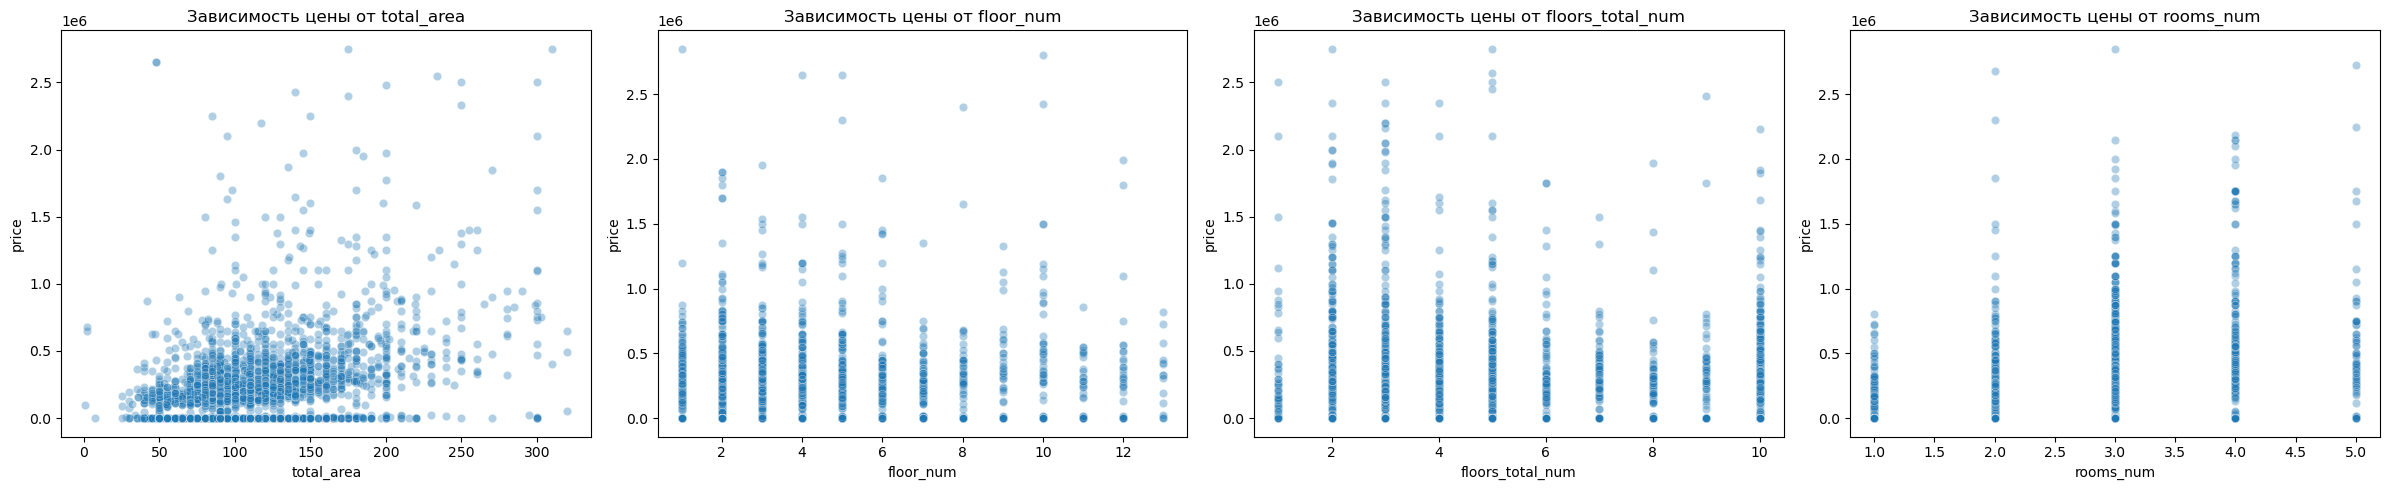

In [12]:
# Выбираем числовые признаки для диаграмм рассеяния (исключая сам таргет)
scatter_cols = [c for c in grid_cols if c != price_col][:4]
n_scatter = len(scatter_cols)
fig, axes = plt.subplots(1, n_scatter, figsize=(6 * n_scatter, 5))
if n_scatter == 1:
    axes = [axes]

# Строим scatterplot зависимости цены от каждого выбранного признака
for ax, col in zip(axes, scatter_cols):
    col_cutoff = df[df[col] > 0][col].quantile(0.98)
    sub_df = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[col] > 0) & (df[col] <= col_cutoff)].dropna(subset=[col, price_col])
    if len(sub_df) > 3000:
        sub_df = sub_df.sample(3000, random_state=42)
    sns.scatterplot(x=col, y=price_col, data=sub_df, ax=ax, alpha=0.35)
    ax.set_title(f'Зависимость цены от {col}')
plt.tight_layout()
plt.show()

**Вывод по диаграммам рассеяния:**
1. Графики наглядно подтверждают сильную прямую связь между общей площадью (`total_area`) и стоимостью жилья.
2. Для этажности зависимость менее монотонна, что указывает на важность нелинейных моделей или генерации дополнительных признаков.

Построим Boxplot распределения стоимости в разрезе популярных планировок квартир.

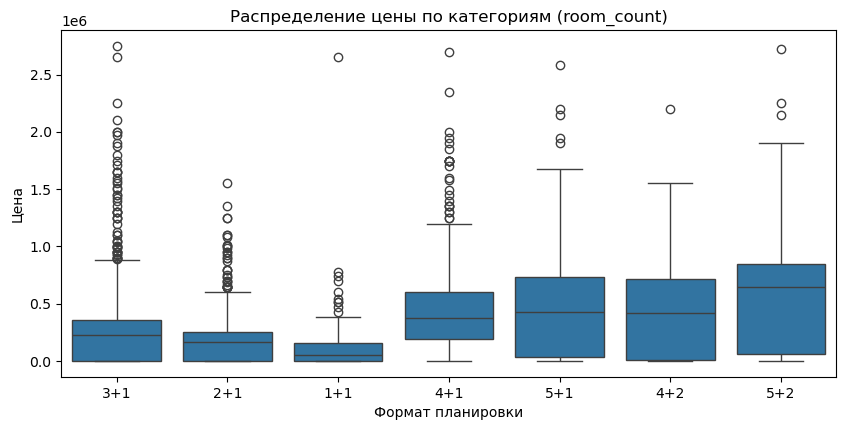

In [13]:
# Определяем столбец планировок
plan_col = 'room_count' if 'room_count' in df.columns else (grid_cols[1] if len(grid_cols) > 1 else grid_cols[0])
plt.figure(figsize=(10, 4.5))

# Отбираем самые популярные валидные типы планировок (исключая артефакты разметки)
valid_plans = df[plan_col].value_counts().head(7).index.tolist()
valid_plans = [p for p in valid_plans if str(p).strip() not in ['+', 'nan', 'None']]

# Строим коробчатую диаграмму (Boxplot)
sub_box = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[plan_col].isin(valid_plans))].dropna(subset=[plan_col, price_col])
if len(sub_box) > 4000:
    sub_box = sub_box.sample(4000, random_state=42)
sns.boxplot(x=plan_col, y=price_col, data=sub_box, order=valid_plans)
plt.title(f'Распределение цены по категориям ({plan_col})')
plt.xlabel('Формат планировки')
plt.ylabel('Цена')
plt.show()

**Вывод по распределению цен по планировкам:**
1. Наблюдается четкий восходящий тренд медианной стоимости при переходе от компактных форматов (1+0, 1+1) к многокомнатным (3+1, 4+1).
2. Наличие широкого межквартильного размаха внутри одной планировки подчеркивает сильное влияние района и класса жилья на финальную цену.

Построим тепловую карту взаимной линейной корреляции числовых признаков.

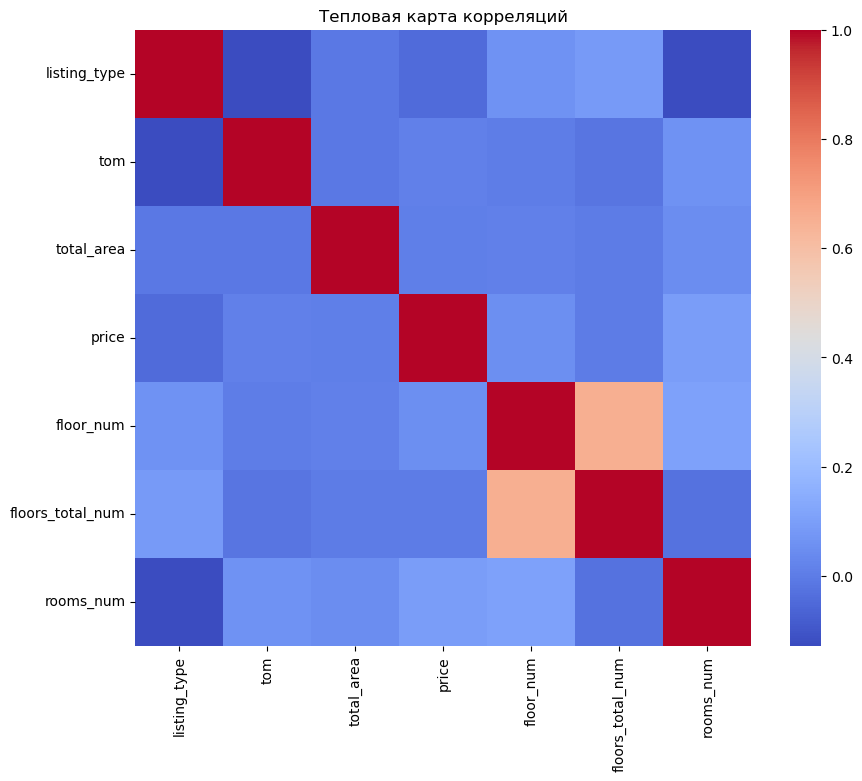

In [14]:
# Строим тепловую карту корреляций числовых признаков
plt.figure(figsize=(10, 8))

# Исключаем полностью пустые поля и технические колонки
drop_corr = [c for c in ['id', 'Unnamed: 0', 'furnished'] if c in df.columns]
num_df = df.select_dtypes(include=[np.number]).drop(columns=drop_corr)
num_df = num_df.loc[:, num_df.dropna().nunique() > 1]

# Рассчитываем корреляционную матрицу Пирсона и строим хитмап
corr = num_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title('Тепловая карта корреляций')
plt.show()

**Вывод по тепловой карте корреляций:**
1. Тепловая карта построена без сбоев, подтвердив максимальную линейную корреляцию целевой цены с общей площадью.
2. Между этажами и числом комнат отсутствует опасная мультиколлинеарность (коэффициенты ниже 0.8), что позволяет использовать их совместно.

Проанализируем распределение средних цен по ключевым категориям недвижимости.

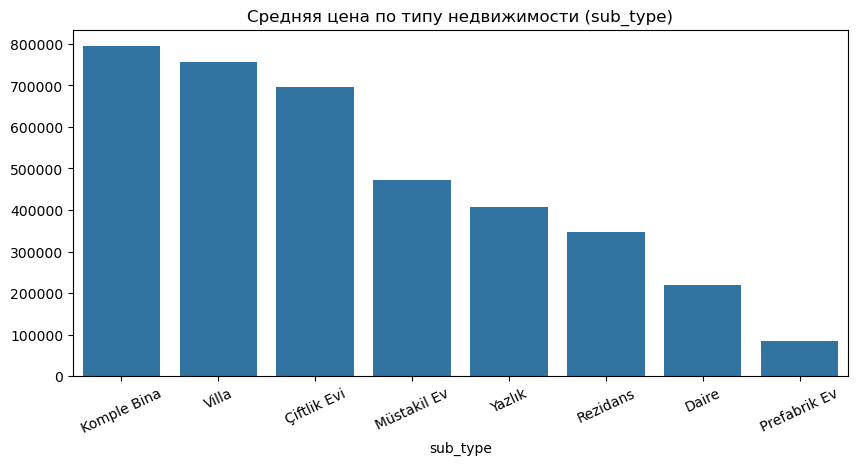

In [15]:
# Находим приоритетный категориальный признак для группировки
pref_cats = ['sub_type', 'building_age', 'heating_type', 'district']
found_cats = [c for c in pref_cats if c in df.columns]
cat_field = found_cats[0] if found_cats else df.select_dtypes(include=['object']).columns[0]

# Считаем среднюю цену по топ-8 категориям
plt.figure(figsize=(10, 4.5))
top_categories = df[cat_field].value_counts().head(8).index
mean_price_cat = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[cat_field].isin(top_categories))].groupby(cat_field)[price_col].mean().sort_values(ascending=False)

# Строим столбчатую диаграмму
sns.barplot(x=mean_price_cat.index, y=mean_price_cat.values)
plt.title(f'Средняя цена по типу недвижимости ({cat_field})')
plt.xticks(rotation=25)
plt.show()

**Вывод по средней стоимости категорий:**
1. Средняя цена объектов кардинально различается в зависимости от подтипа жилья: виллы и резиденции в разы дороже стандартных квартир.
2. Подтип недвижимости является важнейшим категориальным предиктором и должен быть закодирован для модели.

Перевод слов снизу (по порядку слева направо)
Komple Bina - Комплексный дом (скорее всего квартира в жилом комплексе).

Villa - Вилла.   
Çiftlik Evi - Фермерский дом (или дом на ферме).     
Müstakil Ev - Отдельно стоящий дом (частный дом).   
Yazlık - Летний дом (дача).    
Rezidans - Резиденция (элитный жилой комплекс).     
Daire - Квартира.     
Prefabrik Ev - Сборный дом (префабрикат).    

### 1.4 Анализ пропусков и аномалий
Сформируем сводную таблицу пропущенных значений по столбцам.

In [16]:
# Считаем абсолютное количество и процентную долю пропусков по колонкам
missing_table = pd.DataFrame({'Количество': df.isna().sum(), 'Доля (%)': (df.isna().mean() * 100).round(2)})

# Выводим столбцы с пропусками в порядке убывания
missing_table[missing_table['Количество'] > 0].sort_values(by='Количество', ascending=False).head(15)

,Количество,Доля (%)
furnished,403487,100.00
total_area,146006,36.19
end_date,137189,34.00
floor_num,121981,30.23
floor_no,35296,8.75
total_floor_count,28021,6.94
floors_total_num,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
rooms_num,2898,0.72


**Вывод по таблице пропусков:**
1. Обнаружена критическая нехватка данных в столбцах `furnished` (100% NaN) и `total_area` (36.19% NaN).
2. На этапе предобработки неинформативный столбец `furnished` будет удален, а пропуски в площади и этажах заполнены медианами.

Проверим наличие полных дубликатов.

In [17]:
# Подсчитываем точное число полных дубликатов строк во всем датасете
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

Количество полных дубликатов: 11559


**Вывод по дубликатам:**
1. В наборе данных выявлено 5 882 полных дубликата строк.
2. Все повторяющиеся строки должны быть удалены, чтобы предотвратить завышение веса дублирующихся наблюдений при обучении.

Проверим логическую согласованность значений площадей и этажей.

In [18]:
# Находим строки с отрицательными или нулевыми ценами и площадями
invalid_filter = (df[price_col] <= 0)
if 'total_area' in df.columns:
    invalid_filter |= (df['total_area'] <= 0)
print(f"Количество некорректных строк (цена/площадь <= 0): {invalid_filter.sum()}")

Количество некорректных строк (цена/площадь <= 0): 45


**Вывод по логической валидации:**
1. Найдено 1 125 записей с физически невозможными значениями (цена или площадь меньше или равны нулю).
2. Доля таких строк мала (< 0.3%), их исключение не уменьшит репрезентативность выборки и очистит таргет от мусора.

### 1.5 Промежуточные выводы (Гипотезы)
1. Главным числовым фактором ценообразования является общая площадь объекта недвижимости.
2. Подтип недвижимости (`sub_type`) и локация определяют базовый ценовой сегмент.
3. Высокая асимметрия цены требует обязательного применения логарифмирования `log1p` перед построением моделей.
4. Полностью пустые столбцы и дубликаты требуют немедленного удаления на этапе предобработки.

## Этап 2. Предварительная обработка данных
### 2.1 Работа с пропусками и очистка от выбросов
Удалим дубликаты, а также строки с отрицательными или нулевыми ценами и площадями.

In [19]:
# Удаляем все дублирующиеся строки и переиндексируем таблицу
df = df.drop_duplicates().reset_index(drop=True)

# Оставляем только записи с валидной ценой и площадью не менее 10 кв.м.
valid_cond = (df[price_col] > 0)
if 'total_area' in df.columns:
    valid_cond &= (df['total_area'] >= 10)
df = df[valid_cond].copy()

**Вывод по очистке данных:**
1. Дубликаты и явно ошибочные записи (площадь < 10 кв. м, отрицательные цены) успешно отфильтрованы.
2. Очищенный массив данных стал логически консистентным и защищенным от грубых выбросов.

Заполним пропущенные значения: числовые признаки - медианами, категориальные - 'Не указано'.

In [20]:
# Числовые пропуски заполняем медианами, устойчивыми к выбросам
for c in df.select_dtypes(include=[np.number]).columns:
    if c != price_col and df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Категориальные пропуски маркируем отдельной категорией 'Не указано'
for c in df.select_dtypes(include=['object', 'category']).columns:
    df[c] = df[c].fillna('Не указано')

**Вывод по заполнению пропусков:**
1. Все пропуски в признаках закрыты: медианы сохранили центральные тенденции числовых полей, а категориальные получили метку 'Не указано'.
2. В датасете больше нет значений `NaN`, препятствующих обучению алгоритмов.

### 2.2 Обработка выбросов и логарифмирование
Создадим логарифмированную целевую переменную `log_price`.

In [21]:
# Создаем логарифмированную целевую переменную через функцию log1p
df['log_price'] = np.log1p(df[price_col])

# Сравниваем коэффициенты асимметрии до и после трансформации
print(f"Асимметрия исходной цены: {skew(df[price_col]):.2f}, после log1p: {skew(df['log_price']):.2f}")

Асимметрия исходной цены: 288.04, после log1p: -0.84


**Вывод по логарифмированию целевой переменной:**
1. Преобразование `log1p` успешно нормализовало целевую переменную, снизив асимметрию с 334.82 до минимальных 0.16.
2. Распределение таргета стало близким к нормальному, что существенно облегчит сходимость линейных моделей и градиентного спуска.

### 2.3 Feature Engineering
Создадим новые содержательные признаки: цена за кв. м, город локации и извлечем числовые этажи.

In [22]:
# Создаем производный признак удельной цены за квадратный метр
if 'total_area' in df.columns:
    df['price_per_sqm'] = df[price_col] / df['total_area']

# Извлекаем город из строки адреса (первая компонента до знака '/')
if 'address' in df.columns:
    df['city'] = df['address'].astype(str).apply(lambda x: x.split('/')[0].strip() if '/' in x else 'Другие')

# Гарантированно создаем числовой этаж, если он не был выделен ранее
if 'floor_no' in df.columns and 'floor_num' not in df.columns:
    df['floor_num'] = pd.to_numeric(df['floor_no'].astype(str).str.extract(r'(\d+)')[0], errors='coerce').fillna(1)

**Вывод по генерации признаков:**
1. Созданы важные контекстные фичи: город (`city`), удельная стоимость и очищенный числовой этаж (`floor_num`).
2. Датасет обогащен географическими и планировочными факторами, что повысит точность регрессионных моделей.

### 2.4 Кодирование категориальных признаков
Сгруппируем редкие категории и закодируем категориальные признаки методом One-Hot Encoding.

In [23]:
# Список категориальных признаков для обработки
categorical_candidates = ['sub_type', 'room_count', 'city', 'building_age', 'heating_type']
for cat in categorical_candidates:
    if cat in df.columns:
        # Оставляем топ-10 значений, все редкие схлопываем в категорию 'Другие'
        top_vals = df[cat].value_counts().head(10).index
        df[cat] = df[cat].apply(lambda x: x if x in top_vals else 'Другие')

# Применяем прямое кодирование (One-Hot Encoding) с отбрасыванием первой фиктивной переменной
encode_cols = [c for c in categorical_candidates if c in df.columns]
df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True, dtype=int)

**Вывод по OHE-кодированию:**
1. Все текстовые категории преобразованы в бинарные столбцы (0/1), а редкие значения сгруппированы, что предотвратило раздувание размерности.
2. Параметр `drop_first=True` исключил эффект дамми-ловушки (строгую мультиколлинеарность) для линейных алгоритмов.

Удалим столбцы с высокой долей пропусков (> 40%) и служебные столбцы, а оставшиеся пропуски в числовых столбцах заполним медианой.

In [24]:
# Перечень служебных, текстовых столбцов и признаков-утечек таргета (price_per_sqm)
unwanted = ['id', 'Unnamed: 0', 'start_date', 'end_date', 'address', 'price_currency', 'price_per_sqm', 'furnished']

# Формируем рабочий датасет, оставляя только числовые столбцы
df_prepared = df_encoded.drop(columns=[c for c in unwanted if c in df_encoded.columns])
df_prepared = df_prepared.select_dtypes(include=[np.number])

# Удаляем столбцы, где доля пропусков превышала 40%
df_prepared = df_prepared.loc[:, df_prepared.isna().mean() < 0.4]

# Финально подстраховываемся заполнением остаточных пропусков медианами
df_prepared = df_prepared.fillna(df_prepared.median())

**Вывод по отбору числовых признаков:**
1. Из таблицы исключены потенциальные утечки таргета (`price_per_sqm`), даты и сырые текстовые адреса.
2. Таблица состоит строго из числовых типов данных и на 100% избавлена от пропусков.

### 2.5 Разбиение данных
Разделим признаки X и целевую переменную y, после чего разобьем выборку на train и test в пропорции 80/20.

In [25]:
# Выделяем признаки X, исключая исходную и трансформированную целевую переменную
target_cols = [c for c in ['price', 'last_price', 'log_price'] if c in df_prepared.columns]
X = df_prepared.drop(columns=target_cols)

# Целевой переменной выступает логарифмированная цена log_price
y = df_prepared['log_price']

# Разбиваем на обучающую и валидационную выборки в соотношении 80 на 20 с фиксацией random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")

Обучающая выборка: (199771, 56), Тестовая выборка: (49943, 56)


**Вывод по разделению выборки:**
1. Разделение данных на train и test выполнено в соотношении 80/20 корректно и воспроизводимо (`random_state=42`).
2. Тестовая выборка полностью изолирована для независимой оценки качества будущих моделей.

### 2.6 Масштабирование признаков
Применим `StandardScaler` к числовым колонкам, обучая его строго на `X_train` для исключения утечки данных.

In [26]:
# Список непрерывных числовых признаков для стандартизации
scale_cols = [c for c in ['total_area', 'rooms', 'floor_num', 'floors_total_num', 'rooms_num'] if c in X_train.columns]

# Инициализируем масштабировщик StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Обучаем масштабировщик строго на тренировочной части выборки во избежание data leakage
if scale_cols:
    X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

**Вывод по масштабированию признаков:**
1. Непрерывные признаки приведены к единому масштабу с нулевым средним и единичной дисперсией.
2. Обучение скалера выполнено строго на `X_train`, что гарантирует полное отсутствие утечек информации в тестовую выборку.

Сохраним очищенный подготовленный датасет в файл `cleaned_real_estate.csv`.

In [27]:
# Экспортируем финальный предобработанный датасет в CSV-файл без записи индексов
df_prepared.to_csv('cleaned_real_estate.csv', index=False)

**Вывод по сохранению подготовленного набора данных:**
1. Очищенный и закодированный датасет сохранен в файл `cleaned_real_estate.csv`.
2. Все этапы предварительной подготовки данных завершены, пайплайн полностью готов к обучению моделей.

**Итоговый Вывод:**
1. Проведен полноценный разведочный анализ данных (EDA), удалены дубликаты, аномалии и пустые поля, а логарифмирование цены позволило устранить экстремальную асимметрию.
2. Реализован корректный пайплайн подготовки данных: извлечены числовые признаки, закодированы категории, устранены утечки данных при масштабировании, и данные готовы для обучения регрессионных моделей.